<!--
README.md
Waterline Tide Sampling Plot
-->

<h1 align="center">🌊 Waterline Tide Sampling by Year and AOI</h1>

<p align="center">
Visualization of tidal levels associated with extracted shoreline waterlines across multiple AOIs and years.
</p>

<hr/>

<h2>📌 Overview</h2>

<p>
This script analyzes the tidal levels (<code>tide_m</code>) associated with shoreline waterlines extracted from satellite imagery.
It compiles shapefile data from multiple Areas of Interest (AOIs) and produces a visualization showing how the sampled tidal levels vary through time.
</p>

<p>
The resulting plot shows:
</p>

<ul>
<li><b>X-axis:</b> Year (1985–2024)</li>
<li><b>Y-axis:</b> Tide level (m)</li>
<li><b>Points:</b> Individual waterlines</li>
<li><b>Colors:</b> Different AOIs</li>
<li><b>Shaded envelopes:</b> Annual tidal range sampled by each AOI</li>
</ul>

<p>
This visualization helps evaluate the tidal conditions under which shoreline waterlines were extracted.
</p>

<hr/>

<h2>📂 Expected Folder Structure</h2>

<pre><code>
│
├── 01_AOI01/
│   └── 04_OUTPUT_2_WATERLINES/
│       ├── 1985/
│       │   └── waterlines.shp
│       ├── 1986/
│       └── ...
│
├── 02_AOI02/
│   └── 04_OUTPUT_2_WATERLINES/
│       ├── 1985/
│       └── ...
│
└── 03_AOI03/
    └── 04_OUTPUT_2_WATERLINES/
        ├── 1985/
        └── ...
</code></pre>

<p>
Each yearly folder must contain a shapefile with a column named:
</p>

<pre><code>
tide_m
</code></pre>

<p>
This column represents the tidal level (in meters) associated with each extracted waterline.
</p>

<hr/>

<h2>⚙️ Workflow</h2>

<p>The script performs the following steps:</p>

<ol>
<li>Mounts Google Drive (Google Colab environment).</li>
<li>Accesses the shared project directory.</li>
<li>Loops through each AOI folder.</li>
<li>Reads yearly shapefiles containing extracted waterlines.</li>
<li>Extracts the <code>tide_m</code> values.</li>
<li>Compiles all records into a unified dataset.</li>
<li>Generates a scatter plot of tide levels by year.</li>
<li>Computes and displays the annual tidal envelope for each AOI.</li>
</ol>

<hr/>

<h2>📊 Output</h2>

<p>The final figure includes:</p>

<ul>
<li>Colored points representing individual waterlines.</li>
<li>Transparent shaded envelopes showing the minimum and maximum tidal levels sampled each year.</li>
<li>Separate envelopes for each AOI.</li>
</ul>

<p>
This allows quick evaluation of:
</p>

<ul>
<li>Tidal variability in the extracted dataset</li>
<li>Sampling consistency across years</li>
<li>Differences between AOIs</li>
</ul>

<hr/>

<h2>📦 Requirements</h2>

<ul>
<li>Python 3.x</li>
<li>Google Colab environment</li>
<li>Access to the shared Google Drive project directory</li>
<li>Python libraries:
<ul>
<li><code>geopandas</code></li>
<li><code>pandas</code></li>
<li><code>numpy</code></li>
<li><code>matplotlib</code></li>
</ul>
</li>
</ul>

<hr/>

<h2>🧪 Application</h2>

<p>
This analysis is useful for coastal remote sensing workflows based on the waterline method.
It allows researchers to assess the tidal distribution of extracted shoreline positions and verify whether the dataset adequately samples the intertidal zone.
</p>

<p>
Typical applications include:
</p>

<ul>
<li>Intertidal topography reconstruction</li>
<li>Waterline method validation</li>
<li>Coastal morphodynamic monitoring</li>
<li>Tidal sampling assessment</li>
</ul>

<hr/>

<h2>📄 License</h2>

<p>
Specify your preferred license (e.g., MIT, GPL-3.0, CC-BY).
</p>

<hr/>

<p align="center">
<sub>Developed for coastal monitoring workflows and waterline-based shoreline analysis 🌊</sub>
</p>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np


Definir caminho do projeto

In [10]:
ROOT = "/content/drive/Shareddrives/Batimetrias_Babitonga"

AOIS = [
    "01_AOI01",
    "02_AOI02",
    "03_AOI03"
]

AOI_LABELS = {
    "01_AOI01": "AOI 1",
    "02_AOI02": "AOI 2",
    "03_AOI03": "AOI 3"
}

Ler todos os shapefiles automaticamente

In [4]:
records = []

for aoi in AOIS:

    wl_dir = os.path.join(ROOT, aoi, "04_OUTPUT_2_WATERLINES")

    if not os.path.exists(wl_dir):
        continue

    # percorre anos
    year_folders = os.listdir(wl_dir)

    for year in year_folders:

        year_path = os.path.join(wl_dir, year)

        if not os.path.isdir(year_path):
            continue

        # encontra shapefile dentro da pasta
        shp_files = glob.glob(os.path.join(year_path, "**", "*.shp"), recursive=True)

        for shp in shp_files:

            try:
                gdf = gpd.read_file(shp)

                if "tide_m" not in gdf.columns:
                    continue

                for val in gdf["tide_m"]:
                    records.append({
                        "year": int(year),
                        "tide_m": float(val),
                        "AOI": aoi
                    })

            except:
                print("Erro ao ler:", shp)

Criar tabela consolidada

In [5]:
df = pd.DataFrame(records)

print(df.head())
print("Total waterlines:", len(df))

   year  tide_m       AOI
0  1986    0.12  01_AOI01
1  1986    0.12  01_AOI01
2  1986    0.12  01_AOI01
3  1986    0.12  01_AOI01
4  1986    0.12  01_AOI01
Total waterlines: 737700


Preparar envelope (min–max) e estatísticas por ano

In [36]:
# Garantias
df = df.dropna(subset=["year", "tide_m", "AOI"]).copy()
df["year"] = df["year"].astype(int)
df["tide_m"] = pd.to_numeric(df["tide_m"], errors="coerce")
df = df.dropna(subset=["tide_m"])

# Envelope por ano (considera todas as AOIs)
env = (
    df.groupby("year")["tide_m"]
      .agg(tide_min="min", tide_max="max", tide_med="median", n="count")
      .reset_index()
      .sort_values("year")
)

env.head()

,year,tide_min,tide_max,tide_med,n
0,1985,-0.479,0.178,-0.244,16835
1,1986,-0.172,0.120,0.120,14127
2,1987,-0.294,0.296,-0.294,4013
3,1988,-0.336,0.201,-0.074,7685
4,1990,0.339,0.358,0.339,1651


Plotar gráfico

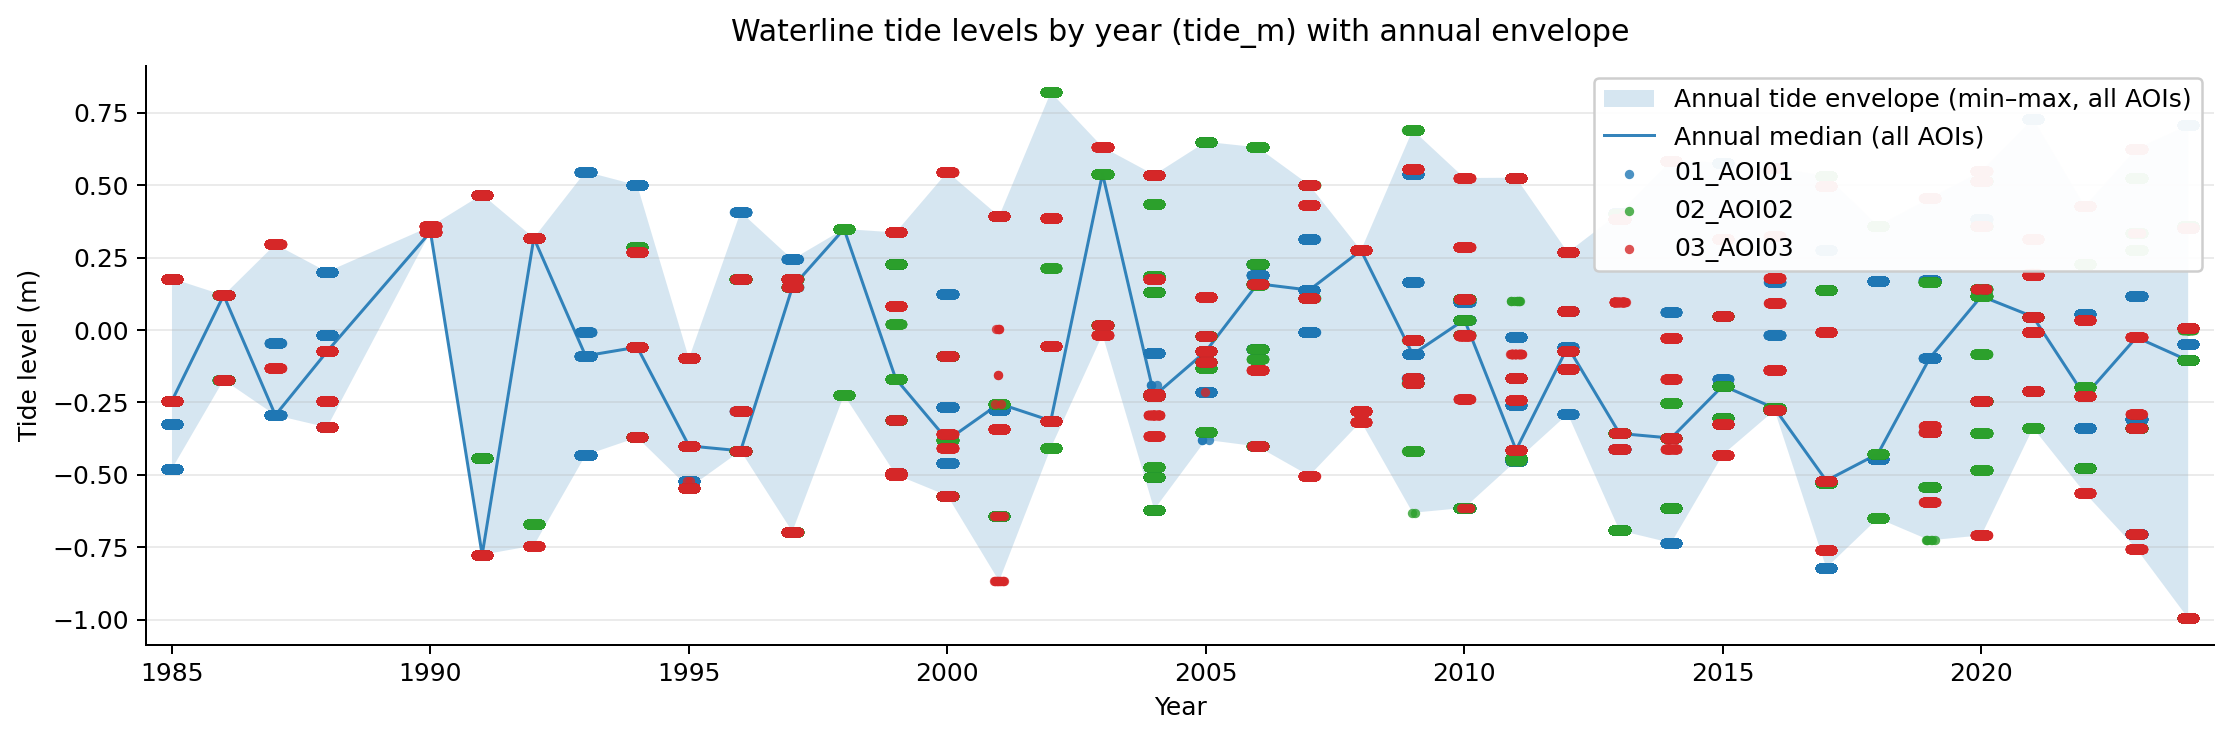

In [37]:
# Paleta simples e consistente (boa pra paper)
AOI_ORDER = ["01_AOI01", "02_AOI02", "03_AOI03"]
COLORS = {
    "01_AOI01": "#1f77b4",  # azul
    "02_AOI02": "#2ca02c",  # verde
    "03_AOI03": "#d62728",  # vermelho
}

YEAR_MIN, YEAR_MAX = 1985, 2024

fig, ax = plt.subplots(figsize=(12.5, 4.2), dpi=180)

# -------------------------
# Envelope min–max por ano
# -------------------------
ax.fill_between(
    env["year"].values,
    env["tide_min"].values,
    env["tide_max"].values,
    alpha=0.18,
    linewidth=0,
    label="Annual tide envelope (min–max, all AOIs)"
)

# Linha da mediana (opcional, mas ajuda MUITO)
ax.plot(
    env["year"].values,
    env["tide_med"].values,
    linewidth=1.2,
    alpha=0.9,
    label="Annual median (all AOIs)"
)

# -------------------------
# Pontos por AOI (paper)
# -------------------------
# Jitter leve no eixo X para reduzir sobreposição (bem sutil)
rng = np.random.default_rng(42)
jitter = 0.12  # ajuste se quiser mais/menos

for aoi in AOI_ORDER:
    d = df[df["AOI"] == aoi].copy()
    if d.empty:
        continue

    x = d["year"].values + rng.uniform(-jitter, jitter, size=len(d))
    y = d["tide_m"].values

    ax.scatter(
        x, y,
        s=14,
        alpha=0.80,
        linewidths=0,
        label=aoi,
        color=COLORS.get(aoi, "0.2"),
        zorder=3
    )

# -------------------------
# Estilo "paper"
# -------------------------
ax.set_title("Waterline tide levels by year (tide_m) with annual envelope", pad=10)
ax.set_xlabel("Year")
ax.set_ylabel("Tide level (m)")

ax.set_xlim(YEAR_MIN - 0.5, YEAR_MAX + 0.5)

# Grid leve
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.grid(False, axis="x")

# Spines limpas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ticks: mostra de 5 em 5 anos (ajuste se quiser)
xticks = np.arange(YEAR_MIN, YEAR_MAX + 1, 5)
ax.set_xticks(xticks)

# Legenda: primeiro envelope/mediana, depois AOIs
handles, labels = ax.get_legend_handles_labels()

# reordena legenda de forma previsível
# (1) envelope, (2) mediana, (3) AOIs
order = []
for key in ["Annual tide envelope (min–max, all AOIs)", "Annual median (all AOIs)"]:
    if key in labels:
        order.append(labels.index(key))
for aoi in AOI_ORDER:
    if aoi in labels:
        order.append(labels.index(aoi))

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    title=None
)

plt.tight_layout()
plt.show()

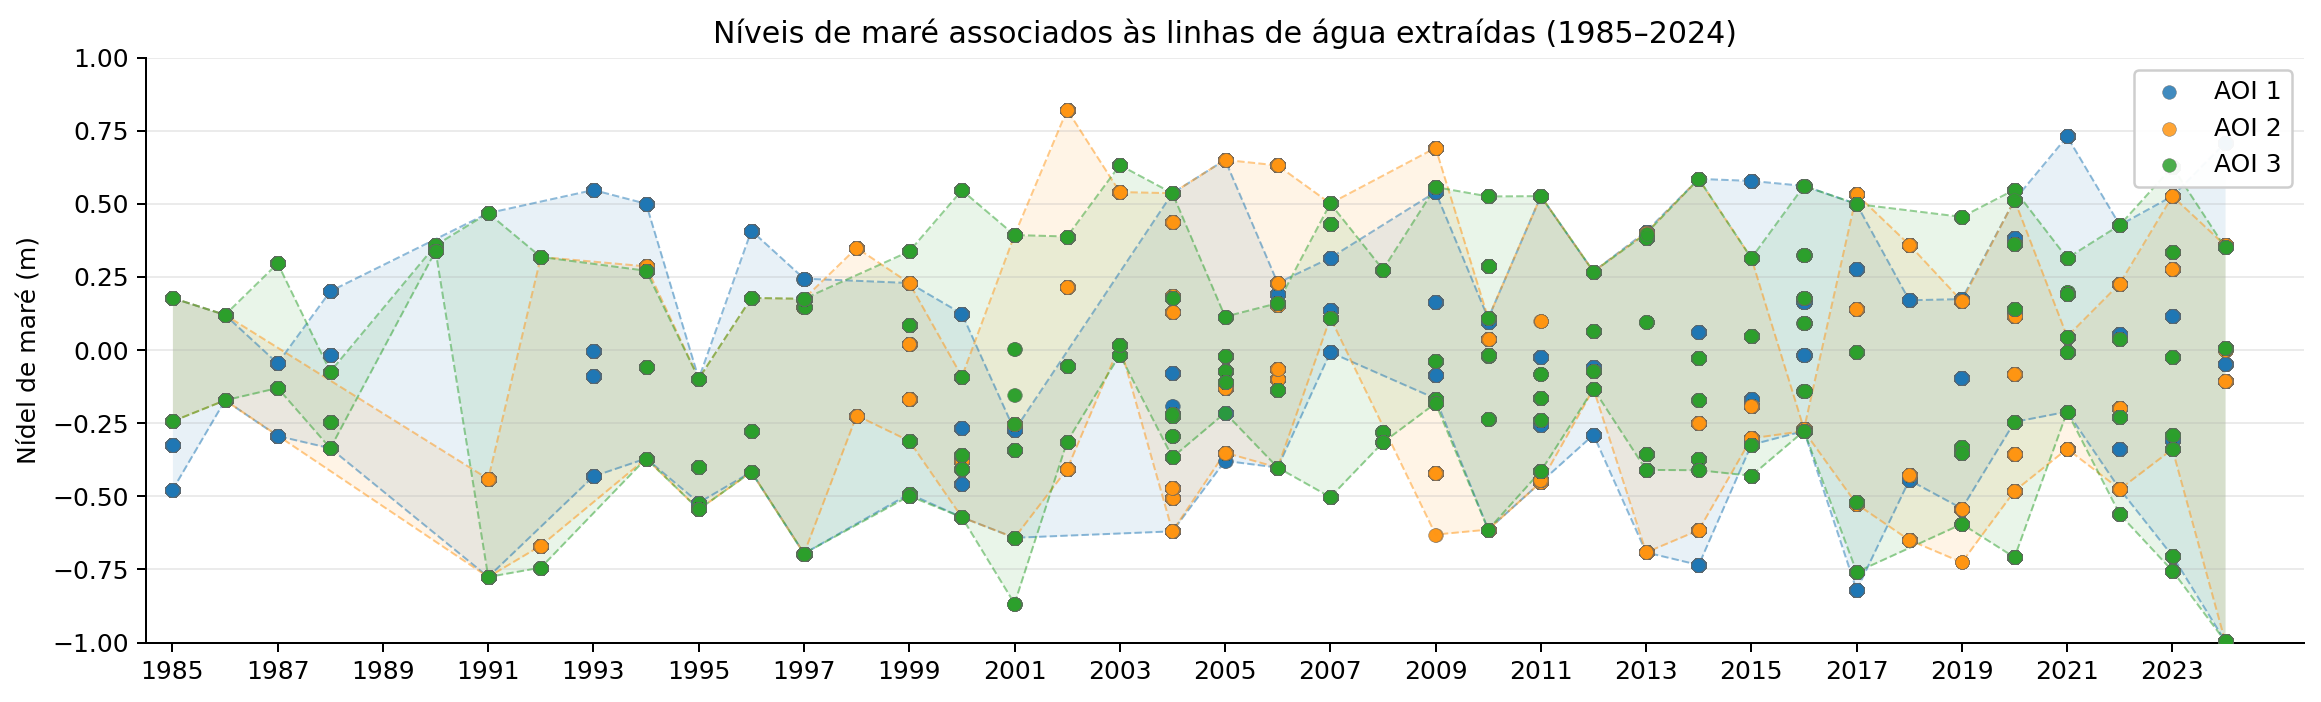

In [48]:
## outra opção
# cores por AOI
COLORS = {
    "01_AOI01": "#1f77b4",  # azul
    "02_AOI02": "#ff9512",  # laranja
    "03_AOI03": "#2ca02c"   # verde
}

fig, ax = plt.subplots(figsize=(13,4), dpi=180)

rng = np.random.default_rng(42)
jitter = 0.01

for aoi, data in df.groupby("AOI"):

    data = data.sort_values("year")

    # -----------------------------
    # Envelope por ano
    # -----------------------------
    env = (
        data.groupby("year")["tide_m"]
        .agg(["min","max"])
        .reset_index()
    )
    aoi_color = COLORS.get(aoi, "0.2")  # fallback seguro
    # preenchimento transparente
    ax.fill_between(
        env["year"],
        env["min"],
        env["max"],
        color=COLORS[aoi],
        alpha=0.1,
        linewidth=0,
        zorder=1
    )

    # linha superior
    ax.plot(
        env["year"],
        env["max"],
        color=COLORS[aoi],
        linewidth=0.8,
        alpha=0.5,
        linestyle="--",
        zorder=2
    )

    # linha inferior
    ax.plot(
        env["year"],
        env["min"],
        color=COLORS[aoi],
        linewidth=0.8,
        alpha=0.5,
        linestyle="--",
        zorder=2
    )

    # -----------------------------
    # Pontos das waterlines
    # -----------------------------
    x = data["year"] + rng.uniform(-jitter, jitter, size=len(data))

    ax.scatter(
        x,
        data["tide_m"],
        s=30,
        marker="o",   # garante bolinha
        edgecolors="0.4",
        linewidth=0.2,
        alpha=0.85,
        color=aoi_color,
        label=AOI_LABELS.get(aoi, aoi),
        zorder=3
    )

# -----------------------------
# Estilo paper
# -----------------------------
ax.set_title("Níveis de maré associados às linhas de água extraídas (1985–2024)")
ax.set_ylabel("Nídel de maré (m)")

ax.set_xlim(1984.5, 2024.5)
ax.set_ylim(-1.00, 1.00)

# grid leve
ax.grid(True, axis='y', alpha=0.25)
ax.grid(False, axis='x')

# remover bordas superiores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ticks a cada 5 anos
ax.set_xticks(np.arange(1985, 2025, 2))

# legenda
ax.legend(
    frameon=True,
    framealpha=0.95,
    loc="upper right"
)

plt.tight_layout()
out_png = "waterline_tide_sampling_by_AOI_1985_2024.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()


In [46]:
from google.colab import files
files.download(out_png)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>